In [2]:
import polars as pl
import pandas as pd


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime, timedelta
import os
from pathlib import Path

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("crest")
warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

customers = pd.read_csv('customers.csv', encoding='latin1')
history = pd.read_csv('customer_history.csv', delimiter=';', encoding='latin1')
train_ref = pd.read_csv('referance_data.csv', encoding='latin1')
test_ref = pd.read_csv('referance_data_test.csv', encoding='latin1')

In [3]:
print(customers.info())
print(customers.describe())
print(customers.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176293 entries, 0 to 176292
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   cust_id      176293 non-null  int64 
 1   gender       176293 non-null  object
 2   age          176293 non-null  int64 
 3   province     176293 non-null  object
 4   religion     176293 non-null  object
 5   work_type    176293 non-null  object
 6   work_sector  146159 non-null  object
 7   tenure       176293 non-null  int64 
dtypes: int64(3), object(5)
memory usage: 10.8+ MB
None
             cust_id            age         tenure
count  176293.000000  176293.000000  176293.000000
mean    99990.772838      43.638091     135.612055
std     57726.621406      14.551524      73.469819
min         0.000000      19.000000      19.000000
25%     49963.000000      31.000000      71.000000
50%    100022.000000      43.000000     132.000000
75%    149968.000000      55.000000     197.000000
max   

📊 Veri Boyutu: (176293, 8)

📋 Veri Tipleri:
 cust_id         int64
gender         object
age             int64
province       object
religion       object
work_type      object
work_sector    object
tenure          int64
dtype: object

🔍 Eksik Değerler:
 cust_id            0
gender             0
age                0
province           0
religion           0
work_type          0
work_sector    30134
tenure             0
dtype: int64

📊 gender sütunundaki benzersiz değer sayısı: 2
gender
F    90508
M    85785
Name: count, dtype: int64

📊 province sütunundaki benzersiz değer sayısı: 12
province
ZUI    37673
NOH    29362
NOB    26112
GEL    21238
UTR    13685
Name: count, dtype: int64

📊 religion sütunundaki benzersiz değer sayısı: 5
religion
U    70559
C    52542
J    18089
M    17987
O    17116
Name: count, dtype: int64

📊 work_type sütunundaki benzersiz değer sayısı: 6
work_type
Full-time        86195
Part-time        44787
Self-employed    15177
Retired          13306
Unemployed       

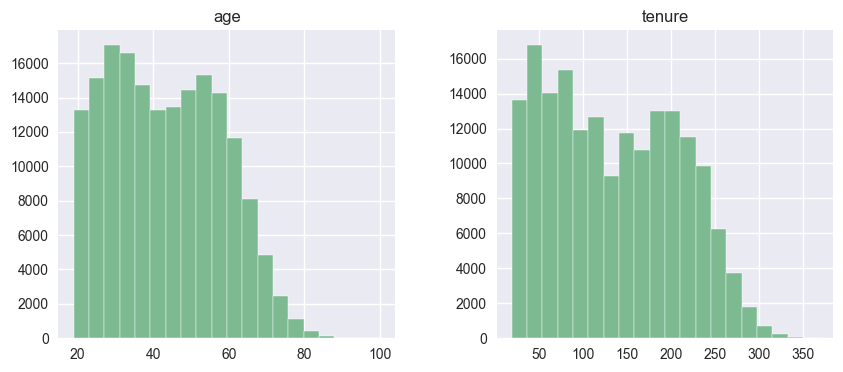

In [4]:

#  Genel Bilgi
print("📊 Veri Boyutu:", customers.shape)
print("\n📋 Veri Tipleri:\n", customers.dtypes)

#  Eksik Değer Analizi
print("\n🔍 Eksik Değerler:\n", customers.isnull().sum())

#  Kategorik Değişkenlerin Dağılımı
cat_cols = customers.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n📊 {col} sütunundaki benzersiz değer sayısı:", customers[col].nunique())
    print(customers[col].value_counts().head())

#  Sayısal Değişkenlerin Dağılım Grafikleri

customers[['age', 'tenure']].hist(figsize=(10, 4), bins=20)
plt.show()


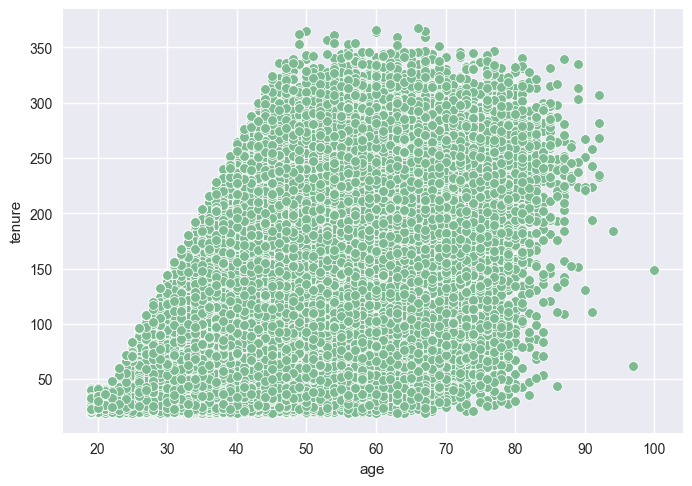

In [5]:
import seaborn as sns
sns.scatterplot(x='age', y='tenure', data=customers)
plt.show()


In [6]:
# 🔍 Eksik Veri Analizi ve Görselleştirme
print("📊 Genel Eksik Veri Durumu:")
print(f"Toplam kayıt sayısı: {len(customers)}")
print(f"work_sector eksik değer sayısı: {customers['work_sector'].isnull().sum()}")
print(f"Eksik veri oranı: {customers['work_sector'].isnull().sum() / len(customers) * 100:.2f}%")

# work_type'a göre eksik work_sector analizi
print("\n🔍 work_type'a göre eksik work_sector analizi:")
missing_analysis = customers.groupby('work_type').agg({
    'work_sector': ['count', lambda x: x.isnull().sum(), lambda x: x.isnull().sum() / len(x) * 100]
}).round(2)

missing_analysis.columns = ['Toplam_Kayıt', 'Eksik_Sayı', 'Eksik_Oran_%']
print(missing_analysis)


📊 Genel Eksik Veri Durumu:
Toplam kayıt sayısı: 176293
work_sector eksik değer sayısı: 30134
Eksik veri oranı: 17.09%

🔍 work_type'a göre eksik work_sector analizi:
               Toplam_Kayıt  Eksik_Sayı  Eksik_Oran_%
work_type                                            
Full-time             86195           0           0.0
Part-time             44787           0           0.0
Retired                   0       13306         100.0
Self-employed         15177           0           0.0
Student                   0        4518         100.0
Unemployed                0       12310         100.0


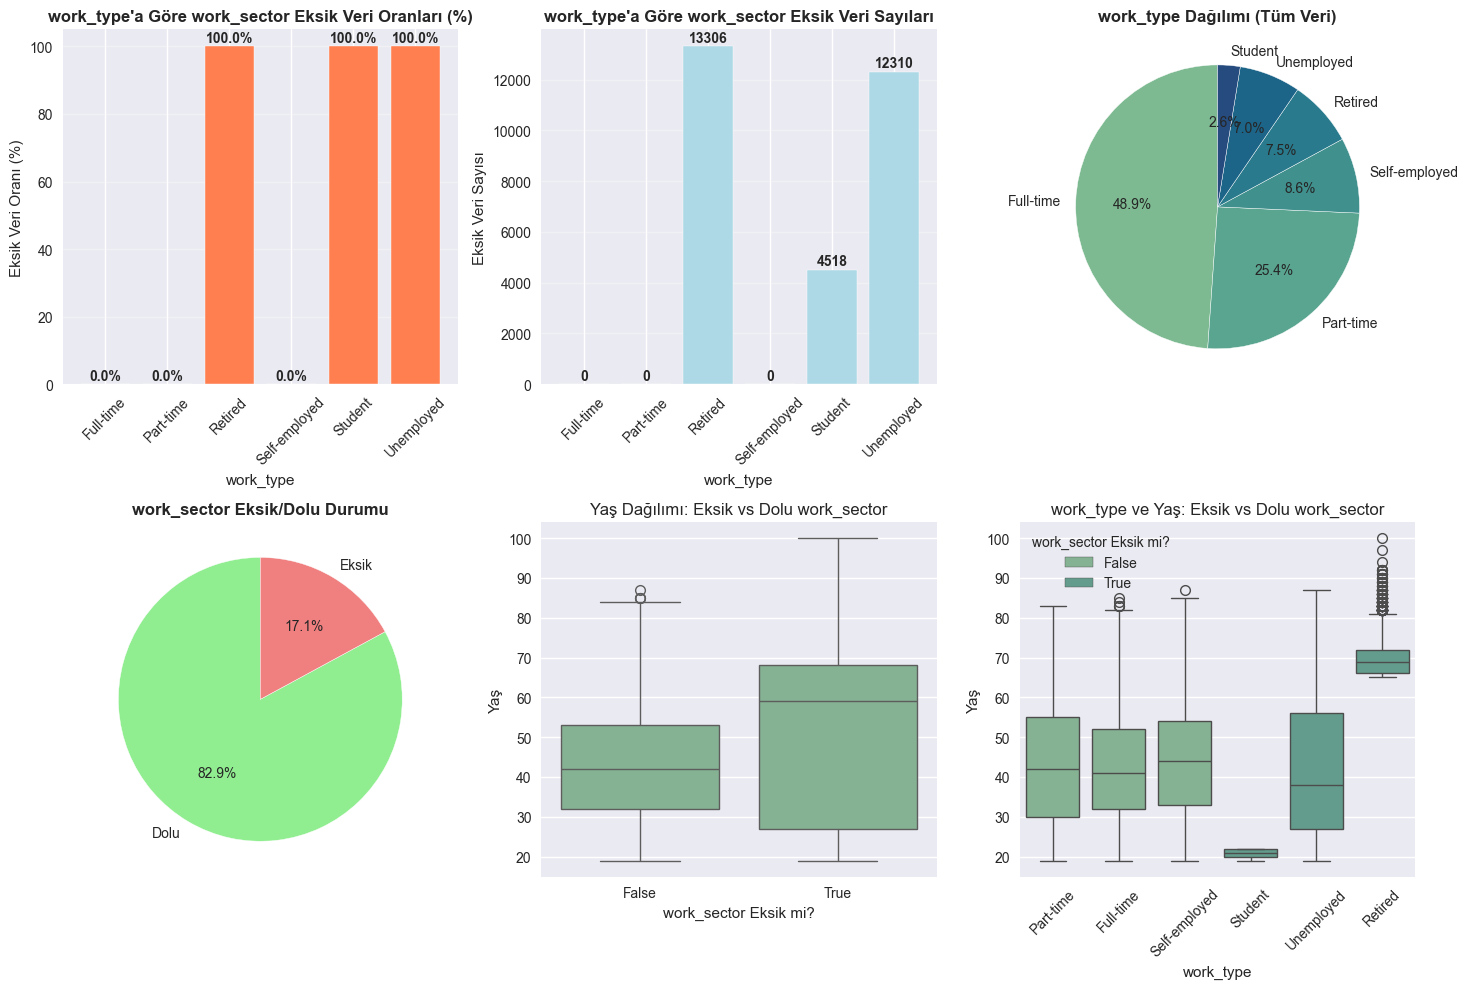

In [7]:
# 📊 Görselleştirme: work_type'a göre eksik veri oranları
plt.figure(figsize=(15, 10))

# Alt grafik 1: Eksik veri oranları
plt.subplot(2, 3, 1)
missing_by_worktype = customers.groupby('work_type')['work_sector'].apply(lambda x: x.isnull().sum() / len(x) * 100)
bars = plt.bar(missing_by_worktype.index, missing_by_worktype.values, color='coral')
plt.title('work_type\'a Göre work_sector Eksik Veri Oranları (%)', fontsize=12, fontweight='bold')
plt.xlabel('work_type')
plt.ylabel('Eksik Veri Oranı (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazdır
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Alt grafik 2: Eksik veri sayıları
plt.subplot(2, 3, 2)
missing_counts = customers.groupby('work_type')['work_sector'].apply(lambda x: x.isnull().sum())
bars2 = plt.bar(missing_counts.index, missing_counts.values, color='lightblue')
plt.title('work_type\'a Göre work_sector Eksik Veri Sayıları', fontsize=12, fontweight='bold')
plt.xlabel('work_type')
plt.ylabel('Eksik Veri Sayısı')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazdır
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 50,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Alt grafik 3: work_type dağılımı (tüm veri)
plt.subplot(2, 3, 3)
worktype_counts = customers['work_type'].value_counts()
plt.pie(worktype_counts.values, labels=worktype_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('work_type Dağılımı (Tüm Veri)', fontsize=12, fontweight='bold')

# Alt grafik 4: Eksik ve dolu work_sector karşılaştırması
plt.subplot(2, 3, 4)
missing_status = customers['work_sector'].isnull()
missing_summary = missing_status.value_counts()
labels = ['Dolu', 'Eksik']
colors = ['lightgreen', 'lightcoral']
plt.pie(missing_summary.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('work_sector Eksik/Dolu Durumu', fontsize=12, fontweight='bold')

# Alt grafik 5: Yaş dağılımı (eksik vs dolu)
plt.subplot(2, 3, 5)
customers['work_sector_missing'] = customers['work_sector'].isnull()
sns.boxplot(data=customers, x='work_sector_missing', y='age')
plt.title('Yaş Dağılımı: Eksik vs Dolu work_sector')
plt.xlabel('work_sector Eksik mi?')
plt.ylabel('Yaş')

# Alt grafik 6: work_type ve yaş ilişkisi
plt.subplot(2, 3, 6)
sns.boxplot(data=customers, x='work_type', y='age', hue='work_sector_missing')
plt.title('work_type ve Yaş: Eksik vs Dolu work_sector')
plt.xlabel('work_type')
plt.ylabel('Yaş')
plt.xticks(rotation=45)
plt.legend(title='work_sector Eksik mi?')

plt.tight_layout()
plt.show()


In [8]:
# 💡 Eksik Veri Doldurma Stratejisi
print("🎯 Doldurma Stratejisi:")
print("Student -> Education")
print("Unemployed -> Not Applicable") 
print("Retired -> Not Applicable")
print("Diğer kategoriler -> Mevcut değerler korunacak")

# Doldurma fonksiyonu
def fill_work_sector(row):
    """
    work_type'a göre work_sector doldurma fonksiyonu
    """
    if pd.isna(row['work_sector']):
        if row['work_type'] == 'Student':
            return 'Education'
        elif row['work_type'] == 'Unemployed':
            return 'Not Applicable'
        elif row['work_type'] == 'Retired':
            return 'Not Applicable'
    return row['work_sector']

# Doldurma işlemi
print(f"\n📊 Doldurma Öncesi:")
print(f"Eksik work_sector sayısı: {customers['work_sector'].isnull().sum()}")

# Doldurma işlemini uygula
customers['work_sector'] = customers.apply(fill_work_sector, axis=1)

print(f"\n✅ Doldurma Sonrası:")
print(f"Eksik work_sector sayısı: {customers['work_sector'].isnull().sum()}")
print(f"Başarıyla doldurulan kayıt sayısı: {30134 - customers['work_sector'].isnull().sum()}")


🎯 Doldurma Stratejisi:
Student -> Education
Unemployed -> Not Applicable
Retired -> Not Applicable
Diğer kategoriler -> Mevcut değerler korunacak

📊 Doldurma Öncesi:
Eksik work_sector sayısı: 30134

✅ Doldurma Sonrası:
Eksik work_sector sayısı: 0
Başarıyla doldurulan kayıt sayısı: 30134


🔍 Doldurma Sonrası work_sector Dağılımı:
work_sector
Not Applicable    25616
Education         23697
Retail            23439
Technology        23265
Healthcare        22579
Public Sector     20559
Manufacturing     20373
Finance           16765
Name: count, dtype: int64

📈 Doldurma Sonrası work_sector Dağılımı (%):
work_sector
Not Applicable    14.53
Education         13.44
Retail            13.30
Technology        13.20
Healthcare        12.81
Public Sector     11.66
Manufacturing     11.56
Finance            9.51
Name: proportion, dtype: float64


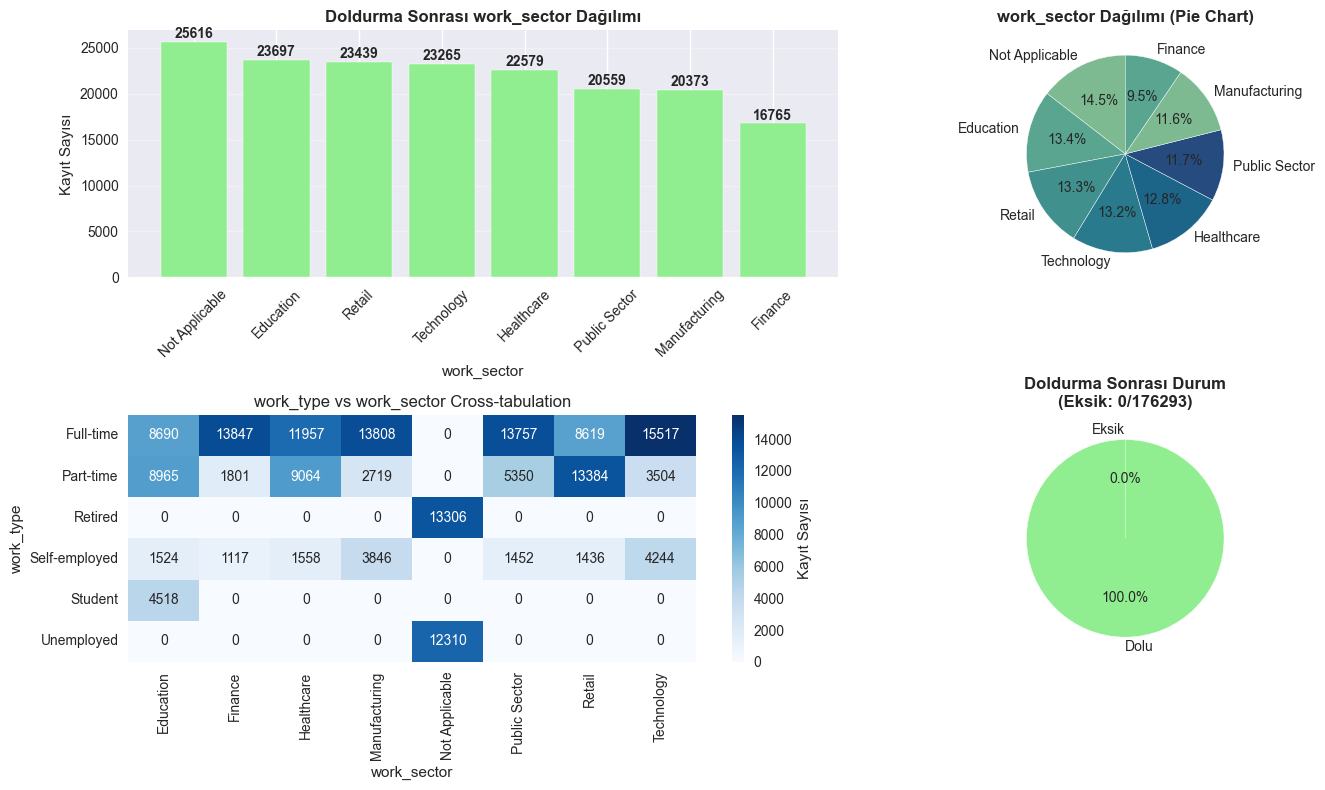

In [9]:
# 📊 Doldurma Sonrası Doğrulama ve Analiz
print("🔍 Doldurma Sonrası work_sector Dağılımı:")
print(customers['work_sector'].value_counts())

print(f"\n📈 Doldurma Sonrası work_sector Dağılımı (%):")
work_sector_pct = customers['work_sector'].value_counts(normalize=True) * 100
print(work_sector_pct.round(2))

# Doldurma sonrası görselleştirme
plt.figure(figsize=(15, 8))

# Alt grafik 1: Doldurma sonrası work_sector dağılımı
plt.subplot(2, 2, 1)
work_sector_counts = customers['work_sector'].value_counts()
bars = plt.bar(range(len(work_sector_counts)), work_sector_counts.values, color='lightgreen')
plt.title('Doldurma Sonrası work_sector Dağılımı', fontsize=12, fontweight='bold')
plt.xlabel('work_sector')
plt.ylabel('Kayıt Sayısı')
plt.xticks(range(len(work_sector_counts)), work_sector_counts.index, rotation=45)
plt.grid(axis='y', alpha=0.3)

# Değerleri bar üzerine yazdır
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Alt grafik 2: Pie chart - work_sector dağılımı
plt.subplot(2, 2, 2)
plt.pie(work_sector_counts.values, labels=work_sector_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('work_sector Dağılımı (Pie Chart)', fontsize=12, fontweight='bold')

# Alt grafik 3: work_type vs work_sector cross-tabulation
plt.subplot(2, 2, 3)
crosstab = pd.crosstab(customers['work_type'], customers['work_sector'])
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Kayıt Sayısı'})
plt.title('work_type vs work_sector Cross-tabulation')
plt.xlabel('work_sector')
plt.ylabel('work_type')

# Alt grafik 4: Eksik veri durumu kontrolü
plt.subplot(2, 2, 4)
missing_after = customers['work_sector'].isnull().sum()
total = len(customers)
labels = ['Dolu', 'Eksik']
sizes = [total - missing_after, missing_after]
colors = ['lightgreen', 'lightcoral']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title(f'Doldurma Sonrası Durum\n(Eksik: {missing_after}/{total})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [10]:
# 💾 Temizlenmiş Veriyi Kaydet
print("💾 Temizlenmiş veriyi kaydediyoruz...")

# Temizlenmiş veriyi yeni bir dosyaya kaydet
customers_cleaned = customers.copy()
customers_cleaned.to_csv('customers_cleaned.csv', index=False, encoding='utf-8')

print("✅ Temizlenmiş veri 'customers_cleaned.csv' dosyasına kaydedildi!")
print(f"📊 Final Durum:")
print(f"   - Toplam kayıt: {len(customers_cleaned)}")
print(f"   - Eksik work_sector: {customers_cleaned['work_sector'].isnull().sum()}")
print(f"   - Doldurma başarı oranı: {((30134 - customers_cleaned['work_sector'].isnull().sum()) / 30134) * 100:.2f}%")

# Özet rapor
print(f"\n📋 Özet Rapor:")
print(f"   - Student kategorisindeki eksik veriler -> 'Education' olarak dolduruldu")
print(f"   - Unemployed kategorisindeki eksik veriler -> 'Not Applicable' olarak dolduruldu") 
print(f"   - Retired kategorisindeki eksik veriler -> 'Not Applicable' olarak dolduruldu")
print(f"   - Diğer kategorilerdeki mevcut veriler korundu")


💾 Temizlenmiş veriyi kaydediyoruz...
✅ Temizlenmiş veri 'customers_cleaned.csv' dosyasına kaydedildi!
📊 Final Durum:
   - Toplam kayıt: 176293
   - Eksik work_sector: 0
   - Doldurma başarı oranı: 100.00%

📋 Özet Rapor:
   - Student kategorisindeki eksik veriler -> 'Education' olarak dolduruldu
   - Unemployed kategorisindeki eksik veriler -> 'Not Applicable' olarak dolduruldu
   - Retired kategorisindeki eksik veriler -> 'Not Applicable' olarak dolduruldu
   - Diğer kategorilerdeki mevcut veriler korundu


In [14]:
customers_cleaned['gender'].unique()

array(['F', 'M'], dtype=object)

In [22]:
customers_cleaned['gender_encoded'] = customers_cleaned['gender'].map({'F': 0, 'M': 1})


In [25]:
customers_cleaned.drop('gender',axis=1,inplace=True)

In [26]:
customers_cleaned.head()

,cust_id,age,province,religion,work_type,work_sector,tenure,work_sector_missing,gender_encoded
0,0,64,NOH,U,Part-time,Technology,135,False,0
1,1,57,ZUI,O,Full-time,Finance,65,False,0
2,2,62,NOB,M,Self-employed,Healthcare,224,False,0
3,3,22,ZUI,C,Student,Education,47,True,0
4,5,27,ZUI,U,Full-time,Finance,108,False,1


array(['NOH', 'ZUI', 'NOB', 'GEL', 'GRO', 'FLE', 'LIM', 'FRI', 'DRE',
       'UTR', 'ZEE', 'OVE'], dtype=object)

In [29]:
# One-Hot Encoding örneği
customers_cleaned = pd.get_dummies(customers_cleaned, columns=['province'], prefix='prov')

# Sonucu kontrol etme
print(customers_cleaned.filter(like='prov_').head())
print(f"Toplam kolon sayısı: {len(customers_cleaned.columns)}")

   prov_DRE  prov_FLE  prov_FRI  prov_GEL  prov_GRO  prov_LIM  prov_NOB  \
0     False     False     False     False     False     False     False   
1     False     False     False     False     False     False     False   
2     False     False     False     False     False     False      True   
3     False     False     False     False     False     False     False   
4     False     False     False     False     False     False     False   

   prov_NOH  prov_OVE  prov_UTR  prov_ZEE  prov_ZUI  
0      True     False     False     False     False  
1     False     False     False     False      True  
2     False     False     False     False     False  
3     False     False     False     False      True  
4     False     False     False     False      True  
Toplam kolon sayısı: 20


In [31]:
customers_cleaned['religion'].value_counts()

religion
U    70559
C    52542
J    18089
M    17987
O    17116
Name: count, dtype: int64

In [32]:
customers_cleaned = pd.get_dummies(customers_cleaned, columns=['religion'], prefix='rel')

In [34]:
customers_cleaned['work_type'].value_counts()

work_type
Full-time        86195
Part-time        44787
Self-employed    15177
Retired          13306
Unemployed       12310
Student           4518
Name: count, dtype: int64

In [37]:
# Zaman serisinde trendleri yakalamak için ordinal encoding
worktype_mapping = {
    'Unemployed': 0,    # En düşük gelir/istihdam
    'Student': 1,       # Düşük gelir, geçici
    'Retired': 2,       # Sabit düşük gelir
    'Part-time': 3,     # Orta gelir
    'Self-employed': 4, # Değişken orta-yüksek gelir
    'Full-time': 5      # En yüksek gelir/istikrar
}

customers_cleaned['work_type_ordinal'] = customers_cleaned['work_type'].map(worktype_mapping)
customers_cleaned.drop('work_type', axis=1, inplace=True)


In [39]:
customers_cleaned['work_sector'].value_counts()

work_sector
Not Applicable    25616
Education         23697
Retail            23439
Technology        23265
Healthcare        22579
Public Sector     20559
Manufacturing     20373
Finance           16765
Name: count, dtype: int64

In [42]:
# Benzer sektörleri gruplandırarak
sector_groups = {
    'Not Applicable': 'Not_Working',
    'Education': 'Public_Services',
    'Public Sector': 'Public_Services',
    'Healthcare': 'Public_Services',
    'Retail': 'Services',
    'Finance': 'Services',
    'Technology': 'Tech_Industry',
    'Manufacturing': 'Industrial'
}

customers_cleaned['sector_grouped'] = customers_cleaned['work_sector'].map(sector_groups)
customers_cleaned = pd.get_dummies(customers_cleaned, columns=['sector_grouped'], prefix='sector')
customers_cleaned.drop('work_sector', axis=1, inplace=True)
customers_cleaned.head()


,cust_id,age,tenure,work_sector_missing,gender_encoded,prov_DRE,prov_FLE,prov_FRI,prov_GEL,prov_GRO,prov_LIM,prov_NOB,prov_NOH,prov_OVE,prov_UTR,prov_ZEE,prov_ZUI,rel_C,rel_J,rel_M,rel_O,rel_U,work_type_ordinal,sector_Industrial,sector_Not_Working,sector_Public_Services,sector_Services,sector_Tech_Industry,sector_Industrial,sector_Not_Working,sector_Public_Services,sector_Services,sector_Tech_Industry,sector_Industrial,sector_Not_Working,sector_Public_Services,sector_Services,sector_Tech_Industry
0,0,64,135,False,0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,3,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True
1,1,57,65,False,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,5,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
2,2,62,224,False,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,4,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False
3,3,22,47,True,0,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,1,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False
4,5,27,108,False,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,5,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
